In [2]:
import sklearn
print(sklearn.__version__)


1.7.2


In [3]:
import pandas as pd

In [4]:
df=pd.read_csv("sensor_data_8flex_new_ka.csv")

In [5]:
df.head()

,idxUp,idxLow,midUp,midLow,ringUp,ringLow,thumb,pinky,label
0,0,0,34,101,32,19,0,45,ka
1,0,0,34,101,34,20,0,42,ka
2,0,0,35,102,34,20,0,42,ka
3,0,0,35,103,35,20,0,42,ka
4,0,0,35,105,35,19,0,42,ka


In [10]:
df['label'] = df['label'].replace({'ka': 0, 'kha': 1, 'ga':2,'gha':3,'ek':4,'dui':5,'tin':6})

/tmp/ipykernel_37229/3339441270.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['label'] = df['label'].replace({'ka': 0, 'kha': 1, 'ga':2,'gha':3,'ek':4,'dui':5,'tin':6})


In [11]:
df.head()

,idxUp,idxLow,midUp,midLow,ringUp,ringLow,thumb,pinky,label
0,0,0,34,101,32,19,0,45,0
1,0,0,34,101,34,20,0,42,0
2,0,0,35,102,34,20,0,42,0
3,0,0,35,103,35,20,0,42,0
4,0,0,35,105,35,19,0,42,0


In [12]:
df.tail()

,idxUp,idxLow,midUp,midLow,ringUp,ringLow,thumb,pinky,label
3495,0,0,0,0,0,0,8,51,6
3496,0,0,0,0,0,0,9,51,6
3497,0,0,0,0,0,0,11,52,6
3498,0,0,0,0,0,0,11,54,6
3499,0,0,0,0,0,0,13,54,6


In [13]:
from sklearn.model_selection import train_test_split

In [14]:
x_train,x_test,y_train,y_test= train_test_split(df.drop(['label'],axis='columns'),df['label'],test_size=0.3)

In [15]:
len(x_train)

2450

In [16]:
x_train

,idxUp,idxLow,midUp,midLow,ringUp,ringLow,thumb,pinky
2085,0,0,66,127,42,22,6,61
3290,0,0,0,0,0,0,29,51
2930,0,0,0,0,46,3,6,47
428,0,8,67,138,46,26,4,51
1358,24,0,61,123,47,20,14,54
...,...,...,...,...,...,...,...,...
2884,0,0,0,0,53,3,9,45
1851,0,0,0,0,0,0,42,0
437,0,8,67,136,46,29,4,54
2992,0,0,0,0,47,5,6,49


In [17]:
x_test

,idxUp,idxLow,midUp,midLow,ringUp,ringLow,thumb,pinky
765,0,0,87,141,49,23,0,47
1071,0,0,66,129,49,24,19,63
842,0,0,85,139,51,27,0,51
274,0,11,73,140,46,27,18,51
1588,0,0,0,0,0,0,29,0
...,...,...,...,...,...,...,...,...
578,0,0,92,145,59,27,0,52
659,0,0,90,144,56,26,0,52
2708,0,0,0,0,51,5,0,57
6,0,0,38,112,39,20,0,42


In [18]:
y_test

765     1
1071    2
842     1
274     0
1588    3
       ..
578     1
659     1
2708    5
6       0
2978    5
Name: label, Length: 1050, dtype: int64

In [19]:
from sklearn.ensemble import RandomForestClassifier

In [20]:
 model=RandomForestClassifier(n_estimators=50)

In [21]:
model.fit(x_train,y_train)

,n_estimators,50
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [22]:
model.score(x_test,y_test)

1.0

In [23]:
y_predicted=model.predict(x_test)

In [24]:
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(y_test,y_predicted)
cm

array([[161,   0,   0,   0,   0,   0,   0],
       [  0, 142,   0,   0,   0,   0,   0],
       [  0,   0, 148,   0,   0,   0,   0],
       [  0,   0,   0, 166,   0,   0,   0],
       [  0,   0,   0,   0, 146,   0,   0],
       [  0,   0,   0,   0,   0, 144,   0],
       [  0,   0,   0,   0,   0,   0, 143]])

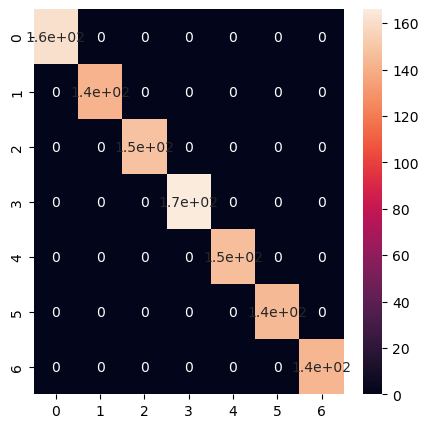

In [25]:
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sm
import numpy as np
plt.figure(figsize=(5,5))
sm.heatmap(cm,annot=True)
plt.xlabel=('predicted')
plt.ylabel=('Truth')

In [26]:
import joblib

joblib.dump(model, "my_model_newSensorData_alpha_new.joblib")
print("Model saved as my_modelnew_alpha_new.joblib")

Model saved as my_modelnew_alpha_new.joblib
